# 0 IMPORTAR LIBRERÍAS NECESARIAS

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.preprocessing import image

# 1 INGESTIÓN O CARGA DE DATOS

In [5]:
# Obtener lista de todas las rutas de las imágenes
image_paths = glob.glob("../data/raw/train/*.jpg") 
""" 1- glob.glob() es como un buscador de archivos
"   2- ../data/raw/train/*.jpg" le dice dónde buscar:  
    3- .. = sube una carpeta (desde src/)
    4- train = entra a esta carpeta
    5- *.jpg = busca TODOS los archivos que terminen en .jpg (el * significa "cualquier nombre")
    6- Guarda todas las rutas de las imágenes encontradas en la variable image_paths"""

print(f"Total de imágenes encontradas: {len(image_paths)}")

# Mostrar algunas rutas de ejemplo
print("\nEjemplos de rutas:")
for path in image_paths[:5]:
    print(path)

Total de imágenes encontradas: 25000

Ejemplos de rutas:
../data/raw/train\cat.0.jpg
../data/raw/train\cat.1.jpg
../data/raw/train\cat.10.jpg
../data/raw/train\cat.100.jpg
../data/raw/train\cat.1000.jpg


# 2 EXPLORAR UNA IMAGEN
Antes de entrenar, veamos cómo se ve una imagen y sus características

Imagen seleccionada: ../data/raw/train\cat.0.jpg
Tipo de dato: <class 'PIL.JpegImagePlugin.JpegImageFile'>


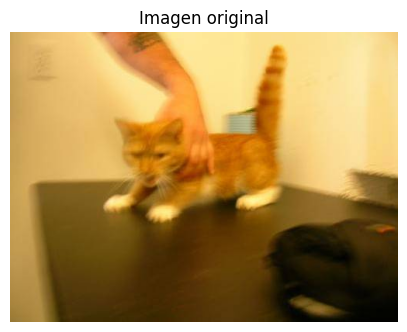

Tamaño de la imagen: (500, 374)


In [6]:
# Cargar UNA imagen de ejemplo
img_path = image_paths[0]  # Tomamos la primera imagen
print(f"Imagen seleccionada: {img_path}")

# Cargar la imagen
img = image.load_img(img_path)  # Carga la imagen
print(f"Tipo de dato: {type(img)}")

# Mostrar la imagen
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title("Imagen original")
plt.axis('off')  # Quita los ejes
plt.show()

# Ver las dimensiones (tamaño) de la imagen
print(f"Tamaño de la imagen: {img.size}")  # (ancho, alto)

# 3 CONVERTIR IMAGEN A NÚMEROS
Las computadoras solo entienden números. Convertimos la imagen a una matriz de números (array)

In [7]:
# Convertir imagen a array (matriz de números)
img_array = image.img_to_array(img)
print(f"Forma del array: {img_array.shape}")  # (alto, ancho, canales de color)
print(f"Rango de valores: {img_array.min()} a {img_array.max()}") # Los colores se forman mezclando 3 colores básicos: Rojo (R), Verde (G), Azul (B). Cada color tiene un valor de 0 a 255

# Ejemplo: ver los primeros valores
print(f"\nPrimeros valores del pixel superior izquierdo:")
print(img_array[0, 0])  # RGB: [Rojo, Verde, Azul]

Forma del array: (374, 500, 3)
Rango de valores: 0.0 a 255.0

Primeros valores del pixel superior izquierdo:
[203. 164.  87.]


# 4 PREPARAR TODAS LAS IMÁGENES
Cargar y preparar todas las imágenes para entrenar el modelo

In [ ]:
# Definir tamaño estándar para todas las imágenes
IMG_SIZE = (224, 224)  # Todas las imágenes tendrán 224x224 pixels (debe coincidir con el modelo)

# Listas para guardar imágenes y etiquetas
images = []
labels = []

# IMPORTANTE: Usar solo un subconjunto de imágenes para no quedarse sin memoria
MAX_IMAGES = 2000  # Procesar solo 2000 imágenes (1000 de cada clase aprox.)

print(f"Cargando máximo {MAX_IMAGES} imágenes...")
for i, img_path in enumerate(image_paths[:MAX_IMAGES]):
    # Cargar imagen con el tamaño definido
    img = image.load_img(img_path, target_size=IMG_SIZE)
    
    # Convertir a array
    img_array = image.img_to_array(img)
    
    # Normalizar: convertir valores de 0-255 a 0-1
    img_array = img_array / 255.0
    
    # Guardar
    images.append(img_array)
    
    # Extraer etiqueta del nombre del archivo
    # Ejemplo: si el archivo se llama "gato_001.jpg", la etiqueta sería "gato"
    label = os.path.basename(img_path).split('.')[0]
    labels.append(label)
    
    if (i + 1) % 200 == 0:
        print(f"Procesadas {i + 1} imágenes...")

print(f"\n✓ Total de imágenes procesadas: {len(images)}")
print(f"✓ Total de etiquetas: {len(labels)}")
print(f"✓ Categorías únicas: {set(labels)}")

Cargando imágenes...
Procesadas 20 imágenes...
Procesadas 40 imágenes...
Procesadas 60 imágenes...
Procesadas 80 imágenes...
Procesadas 100 imágenes...
Procesadas 120 imágenes...
Procesadas 140 imágenes...
Procesadas 160 imágenes...
Procesadas 180 imágenes...
Procesadas 200 imágenes...
Procesadas 220 imágenes...
Procesadas 240 imágenes...
Procesadas 260 imágenes...
Procesadas 280 imágenes...
Procesadas 300 imágenes...
Procesadas 320 imágenes...
Procesadas 340 imágenes...
Procesadas 360 imágenes...
Procesadas 380 imágenes...
Procesadas 400 imágenes...
Procesadas 420 imágenes...
Procesadas 440 imágenes...
Procesadas 460 imágenes...
Procesadas 480 imágenes...
Procesadas 500 imágenes...
Procesadas 520 imágenes...
Procesadas 540 imágenes...
Procesadas 560 imágenes...
Procesadas 580 imágenes...
Procesadas 600 imágenes...
Procesadas 620 imágenes...
Procesadas 640 imágenes...
Procesadas 660 imágenes...
Procesadas 680 imágenes...
Procesadas 700 imágenes...
Procesadas 720 imágenes...
Procesadas 

# 5 CONVERTIR DATOS A FORMATO CORRECTO
Convertir listas a arrays de NumPy y preparar etiquetas

In [29]:
# Convertir listas a arrays de NumPy
X = np.array(images)  # X = datos (imágenes)
print(f"Forma de X: {X.shape}")  # (num_imágenes, alto, ancho, canales)

# Convertir etiquetas de texto a números
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)  # y = etiquetas (0, 1)
print(f"Forma de y: {y.shape}")
print(f"\nEjemplo de conversión:")
print(f"  {labels[0]} → {y[0]}")
print(f"  {labels[100]} → {y[1]}")

MemoryError: Unable to allocate 14.0 GiB for an array with shape (25000, 224, 224, 3) and data type float32

# 5.1 VERIFICAR ETIQUETAS
Comprobar que las etiquetas se extrajeron correctamente

In [19]:
# 1. Ver las primeras 5 y últimas 5 etiquetas
print("Primeras 5 etiquetas:")
for i in range(min(5, len(labels))):
    print(f"  {i}: {labels[i]}")

print("\nÚltimas 5 etiquetas:")
for i in range(max(0, len(labels) - 5), len(labels)):
    print(f"  {i}: {labels[i]}")

# 2. Contar cuántas imágenes hay de cada categoría
from collections import Counter
conteo = Counter(labels)
print(f"\n📊 Conteo por categoría:")
for categoria, cantidad in conteo.items():
    print(f"  {categoria}: {cantidad} imágenes")

# 3. Ver qué categorías únicas existen
print(f"\n🏷️ Categorías únicas encontradas: {sorted(set(labels))}")

# 4. Verificar algunas rutas y sus etiquetas
print(f"\n🔍 Verificación ruta → etiqueta (primeras 4):")
for i in range(min(4, len(image_paths))):
    filename = os.path.basename(image_paths[i])
    print(f"  {i}: {filename} → '{labels[i]}'")

# Verificar posiciones 12501-12504
print(f"\n🔍 Verificación ruta → etiqueta (desde 12501 hasta 12504):")
for i in range(12501, min(12505, len(image_paths))):
    if i < len(image_paths):
        filename = os.path.basename(image_paths[i])
        print(f"  {i}: {filename} → '{labels[i]}'")

Primeras 5 etiquetas:
  0: cat
  1: cat
  2: cat
  3: cat
  4: cat

Últimas 5 etiquetas:
  24995: dog
  24996: dog
  24997: dog
  24998: dog
  24999: dog

📊 Conteo por categoría:
  cat: 12500 imágenes
  dog: 12500 imágenes

🏷️ Categorías únicas encontradas: ['cat', 'dog']

🔍 Verificación ruta → etiqueta (primeras 4):
  0: cat.0.jpg → 'cat'
  1: cat.1.jpg → 'cat'
  2: cat.10.jpg → 'cat'
  3: cat.100.jpg → 'cat'

🔍 Verificación ruta → etiqueta (desde 12501 hasta 12504):
  12501: dog.1.jpg → 'dog'
  12502: dog.10.jpg → 'dog'
  12503: dog.100.jpg → 'dog'
  12504: dog.1000.jpg → 'dog'


# 6 DIVIDIR DATOS EN ENTRENAMIENTO Y PRUEBA
Separar datos: 80% para entrenar, 20% para probar

In [20]:
from sklearn.model_selection import train_test_split

# Dividir datos: 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,  # 20% para pruebas
    random_state=0  
)

print(f"Datos de entrenamiento: {X_train.shape[0]} imágenes")
print(f"Datos de prueba: {X_test.shape[0]} imágenes")

Datos de entrenamiento: 20000 imágenes
Datos de prueba: 5000 imágenes


# 7 CREAR EL MODELO (Red Neuronal)
Construir una red neuronal simple para clasificar imágenes

In [25]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, MaxPool2D, Flatten, Dense

model = Sequential()
model.add(Conv2D(input_shape = (224,224,3), filters = 64, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 64,kernel_size = (3,3),padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Flatten())
model.add(Dense(units = 4096,activation = "relu"))
model.add(Dense(units = 4096,activation = "relu"))
model.add(Dense(units = 2, activation = "softmax"))
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_41 (Conv2D)              │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,268,738 (512.19 MB)

 Trainable params: 134,268,738 (512.19 MB)

 Non-trainable params: 0 (0.00 B)

# 8 COMPILAR EL MODELO
Configurar cómo el modelo aprenderá

In [26]:
# Compilar el modelo
model.compile(
    optimizer='adam',  # Algoritmo para ajustar pesos
    loss='sparse_categorical_crossentropy',  # Función de error
    metrics=['accuracy']  # Métrica para evaluar
)

print("✓ Modelo compilado y listo para entrenar")

✓ Modelo compilado y listo para entrenar


# 9 ENTRENAR EL MODELO
¡Aquí es donde la magia sucede! El modelo aprende de las imágenes

In [27]:
# Entrenar el modelo
history = model.fit(
    X_train, y_train,  # Datos de entrenamiento
    epochs=10,  # Número de veces que verá todos los datos
    validation_data=(X_test, y_test),  # Datos para validar
    verbose=1  # Mostrar progreso
)

print("\n✓ Entrenamiento completado")

Epoch 1/10


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense_9" is incompatible with the layer: expected axis -1 of input shape to have value 25088, but received input with shape (32, 8192)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 150, 150, 3), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

# 10 VISUALIZAR EL APRENDIZAJE
Ver cómo mejoró el modelo durante el entrenamiento

In [ ]:
# Graficar la precisión
plt.figure(figsize=(12, 4))

# Gráfica 1: Precisión
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del Modelo')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

# Gráfica 2: Pérdida (error)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 11 EVALUAR EL MODELO
Verificar qué tan bien funciona el modelo con datos nuevos

In [ ]:
# Evaluar en datos de prueba
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"📊 Resultados en datos de prueba:")
print(f"   Precisión: {test_accuracy * 100:.2f}%")
print(f"   Pérdida: {test_loss:.4f}")

# 12 HACER PREDICCIONES
Usar el modelo para clasificar una imagen nueva

In [ ]:
# Seleccionar una imagen de prueba
test_index = 0
test_image = X_test[test_index]
true_label = y_test[test_index]

# Hacer predicción (necesita dimensión extra)
prediction = model.predict(test_image.reshape(1, 150, 150, 3))
predicted_class = np.argmax(prediction)  # Clase con mayor probabilidad

# Visualizar resultado
plt.figure(figsize=(8, 4))

# Imagen
plt.subplot(1, 2, 1)
plt.imshow(test_image)
plt.title(f"Imagen de prueba")
plt.axis('off')

# Probabilidades
plt.subplot(1, 2, 2)
classes = label_encoder.classes_
plt.barh(classes, prediction[0])
plt.xlabel('Probabilidad')
plt.title('Predicciones del modelo')
plt.tight_layout()
plt.show()

# Resultado
print(f"\n🎯 Predicción:")
print(f"   Clase real: {label_encoder.inverse_transform([true_label])[0]}")
print(f"   Clase predicha: {label_encoder.inverse_transform([predicted_class])[0]}")
print(f"   Confianza: {prediction[0][predicted_class] * 100:.2f}%")

# 13 GUARDAR EL MODELO (OPCIONAL)
Guardar el modelo entrenado para usarlo después sin tener que entrenar de nuevo

In [ ]:
# Guardar el modelo
model.save('../models/image_classifier.h5')
print("✓ Modelo guardado en: ../models/image_classifier.h5")

# Para cargar el modelo después:
# from keras.models import load_model
# model_loaded = load_model('../models/image_classifier.h5')